In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shotquality-rebounding/test_locs.csv
/kaggle/input/shotquality-rebounding/test_pbp.csv
/kaggle/input/shotquality-rebounding/sample_sumbission.csv
/kaggle/input/shotquality-rebounding/train_pbp.csv
/kaggle/input/shotquality-rebounding/train_locs.csv


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
test = pd.read_csv('/kaggle/input/shotquality-rebounding/test_pbp.csv')
test.head()

,id,team,opponent,conference,opp_conference
0,306-28,Connecticut,San Diego St.,BigEast,MWC
1,84-10,Fresno St.,Utah St.,MWC,MWC
2,232-34,Auburn,Arkansas,SEC,SEC
3,184-13,UNLV,San Diego St.,MWC,MWC
4,147-55,Miami FL,Duke,ACC,ACC


In [3]:
train = pd.read_csv('/kaggle/input/shotquality-rebounding/train_pbp.csv')
train.head()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1,Auburn,George Mason,SEC,Atlantic 10


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10


In [6]:
combined.infer_objects()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10
...,...,...,...,...,...,...
5228,167-13,NaN,Creighton,Georgetown,BigEast,BigEast
5229,72-39,NaN,Butler,Creighton,BigEast,BigEast
5230,10-13,NaN,Texas Southern,Auburn,SWAC,SEC
5231,228-13,NaN,Miami FL,Pittsburgh,ACC,ACC


In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17442 entries, 0 to 5232
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              17442 non-null  object 
 1   is_oreb         12209 non-null  float64
 2   team            17442 non-null  object 
 3   opponent        17442 non-null  object 
 4   conference      17442 non-null  object 
 5   opp_conference  17442 non-null  object 
dtypes: float64(1), object(5)
memory usage: 953.9+ KB


In [8]:
combined.dtypes

id                 object
is_oreb           float64
team               object
opponent           object
conference         object
opp_conference     object
dtype: object

In [9]:
combined.shape

(17442, 6)

In [10]:
combined.isnull().sum()/len(combined)*100

id                 0.000000
is_oreb           30.002293
team               0.000000
opponent           0.000000
conference         0.000000
opp_conference     0.000000
dtype: float64

<Axes: >

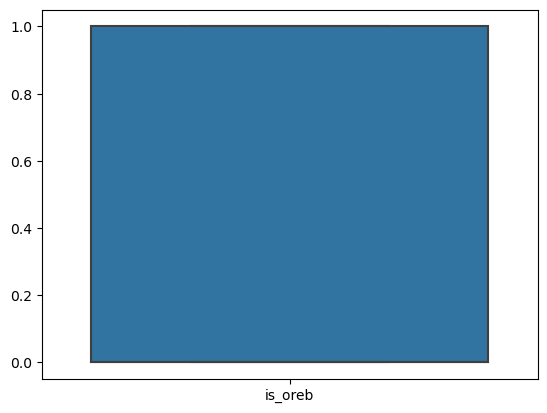

In [11]:
sns.boxplot(combined)

<Axes: >

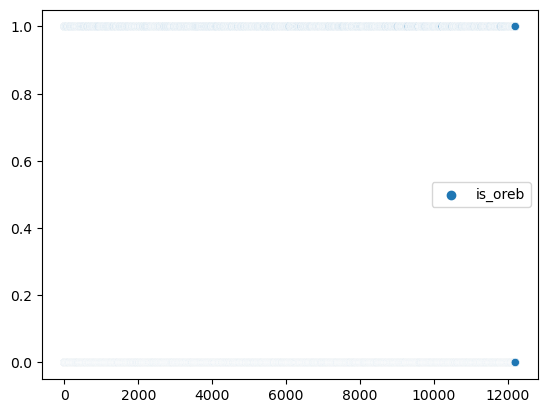

In [12]:
sns.scatterplot(combined)

<Axes: >

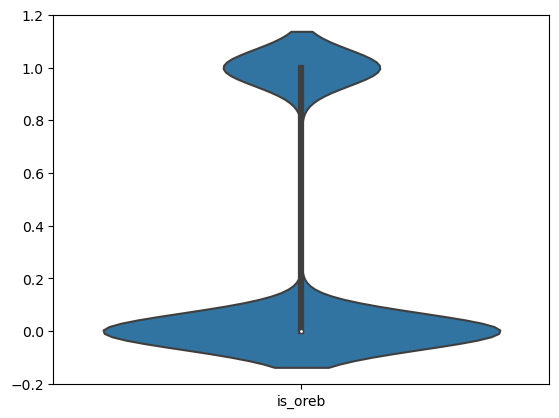

In [13]:
sns.violinplot(combined)

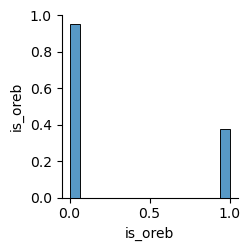

In [14]:
sns.pairplot(combined)

<Axes: ylabel='Density'>

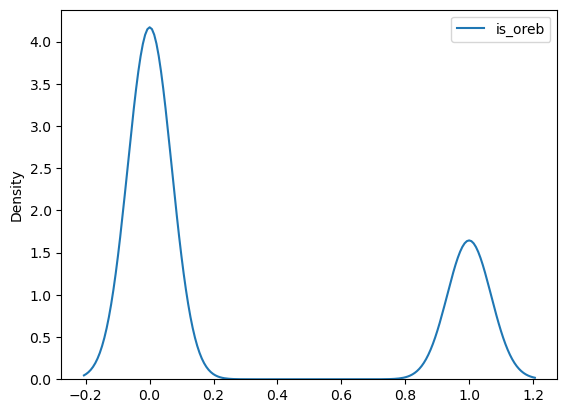

In [15]:
sns.kdeplot(combined)

<Axes: >

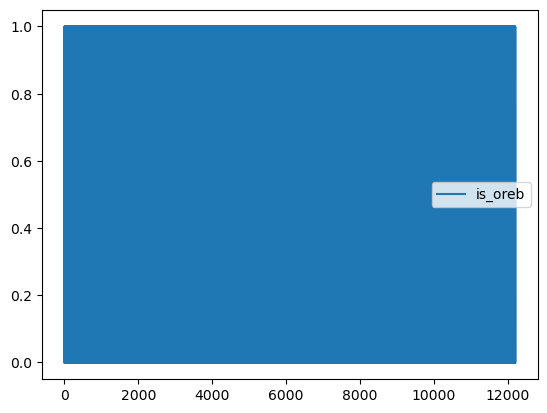

In [16]:
sns.lineplot(combined)

/tmp/ipykernel_32/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

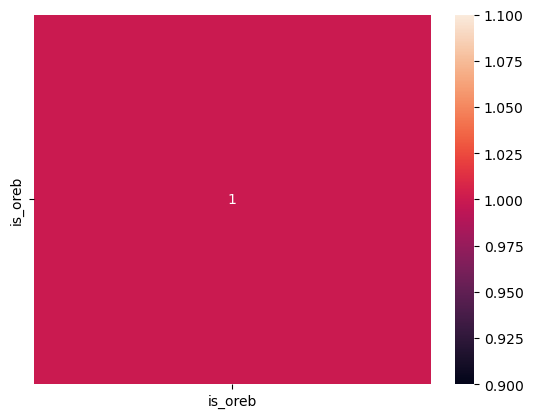

In [17]:
sns.heatmap(combined.corr(),annot=True)

<Axes: >

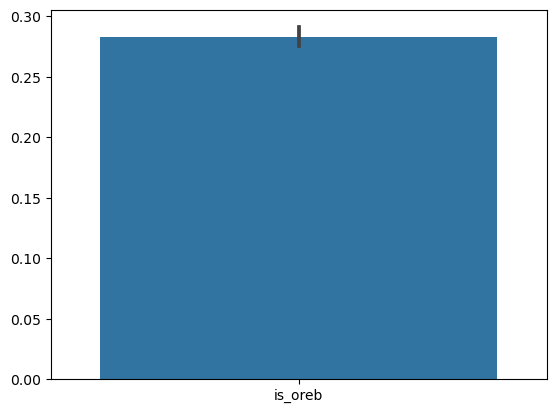

In [18]:
sns.barplot(combined)

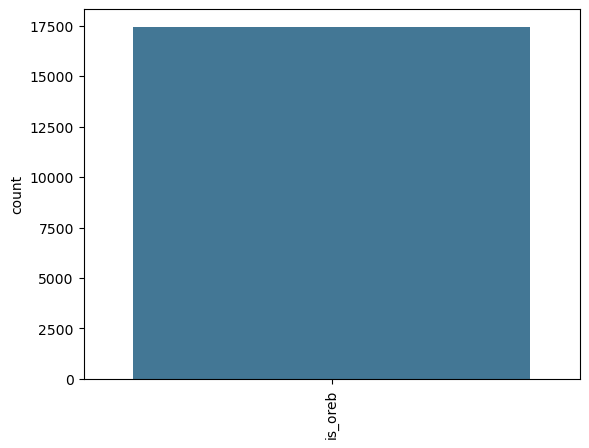

In [19]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

In [20]:
combined.head()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10


In [5]:
cat_cols = combined.select_dtypes(include='object')

In [6]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

id
1-1       1
292-35    1
292-42    1
292-41    1
292-39    1
         ..
145-27    1
145-28    1
145-29    1
145-32    1
190-31    1
Name: id, Length: 17442, dtype: int64
__________________________________________________
team
UNLV                 914
Auburn               912
Creighton            824
Florida              787
Texas                771
                    ... 
UC Santa Barbara      20
Southern Illinois     20
Utah Valley           18
Portland              18
VCU                    7
Name: team, Length: 142, dtype: int64
__________________________________________________
opponent
Creighton      1011
Auburn          965
UNLV            842
Florida         834
Duke            776
               ... 
Oregon St.       20
Ohio             19
Louisiana        18
Georgia St.      18
Portland         16
Name: opponent, Length: 141, dtype: int64
__________________________________________________
conference
SEC                             4451
ACC                             2158


In [7]:
num_cols = combined.select_dtypes(include='number')

In [8]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

is_oreb
0.0    8755
1.0    3454
Name: is_oreb, dtype: int64
__________________________________________________


/tmp/ipykernel_32/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


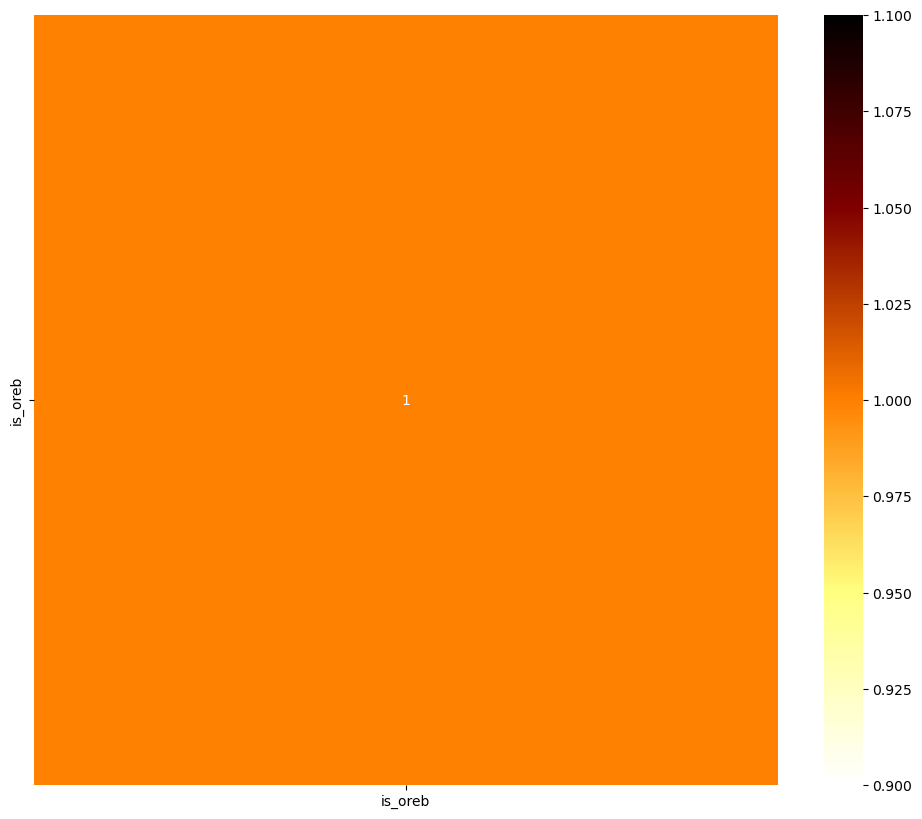

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

/n


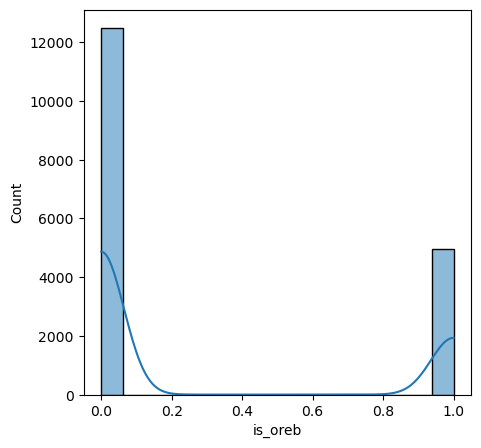

In [26]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('/n')
    plt.show()

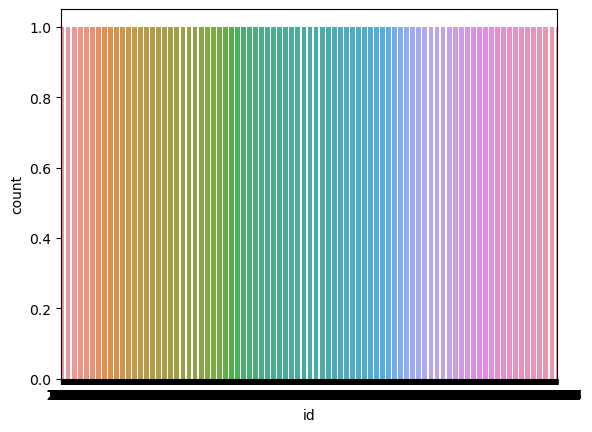

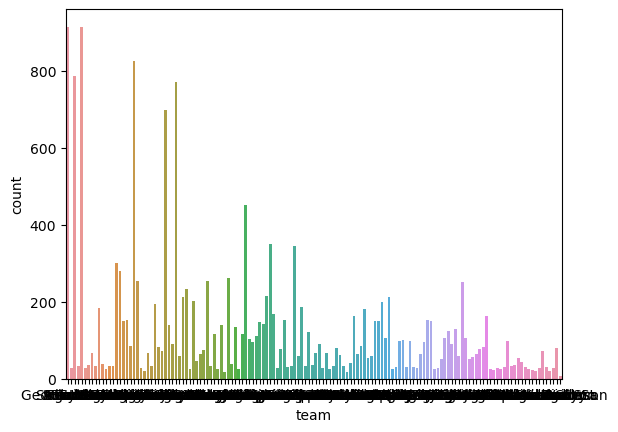

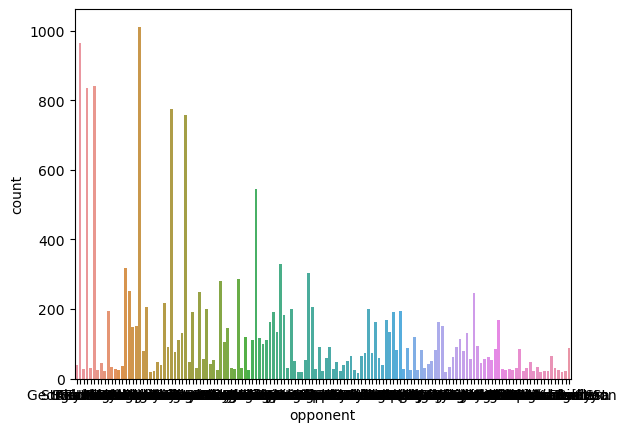

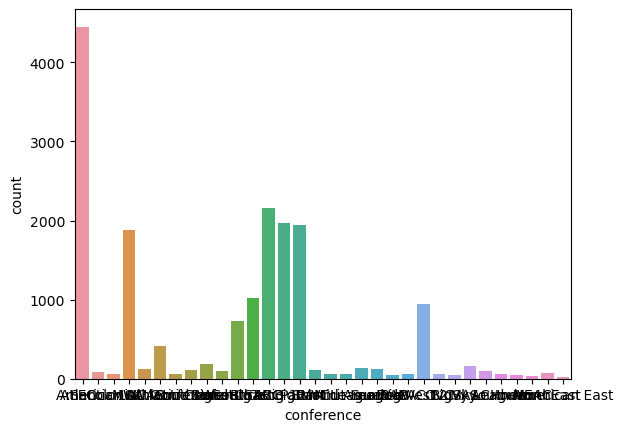

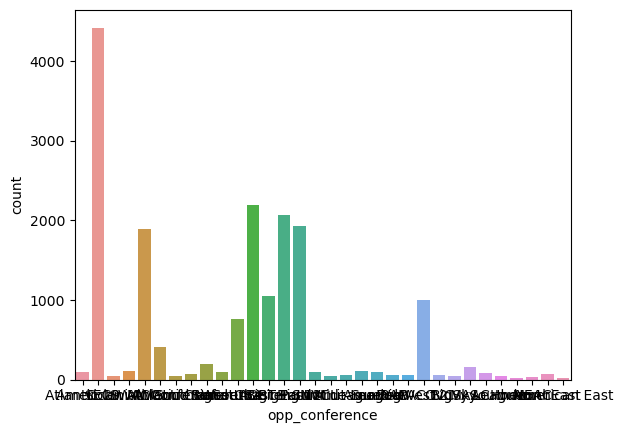

In [27]:
x=1
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

In [28]:
# replacing weird values
combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [29]:
combined.head()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10


In [30]:
# Treating type of id
combined['id'].value_counts().head(9).index[1:]

Index(['292-35', '292-42', '292-41', '292-39', '292-38', '292-37', '292-36',
       '292-34'],
      dtype='object')

In [31]:
# Rebuild type of id columns
for i in combined['id'].value_counts().head(9).index[1:]:
    combined[i]=combined['id'].str.contains(i)

In [32]:
combined.head()

,id,is_oreb,team,opponent,conference,opp_conference,292-35,292-42,292-41,292-39,292-38,292-37,292-36,292-34
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10,False,False,False,False,False,False,False,False
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC,False,False,False,False,False,False,False,False
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10,False,False,False,False,False,False,False,False
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC,False,False,False,False,False,False,False,False
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10,False,False,False,False,False,False,False,False


In [33]:
combined.drop('id',inplace=True,axis=1)

In [34]:
mapping = combined.groupby('is_oreb')['292-35'].mean().to_dict()

In [35]:
combined['292-35']=combined['is_oreb'].map(mapping)

In [36]:
combined['is_oreb']=round(combined['is_oreb'],0)

In [37]:
combined['is_oreb']=combined['is_oreb'].astype(str)

In [38]:
combined.head()

,is_oreb,team,opponent,conference,opp_conference,292-35,292-42,292-41,292-39,292-38,292-37,292-36,292-34
0,0.0,Auburn,George Mason,SEC,Atlantic 10,0.00000,False,False,False,False,False,False,False
1,0.0,George Mason,Auburn,Atlantic 10,SEC,0.00000,False,False,False,False,False,False,False
2,1.0,Auburn,George Mason,SEC,Atlantic 10,0.00029,False,False,False,False,False,False,False
3,0.0,George Mason,Auburn,Atlantic 10,SEC,0.00000,False,False,False,False,False,False,False
4,1.0,Auburn,George Mason,SEC,Atlantic 10,0.00029,False,False,False,False,False,False,False


In [39]:
combined.isnull().sum()

is_oreb              0
team                 0
opponent             0
conference           0
opp_conference       0
292-35            5233
292-42               0
292-41               0
292-39               0
292-38               0
292-37               0
292-36               0
292-34               0
dtype: int64

In [40]:
# Replacing  292-42
combined['292-42']=combined['292-42'].replace({'NM':'Other'})

In [41]:
combined['292-42'].value_counts()

False    17441
True         1
Name: 292-42, dtype: int64

In [42]:
combined['292-42']=combined['292-42'].replace({-1.0:1.0})

In [43]:
combined['292-42'].value_counts()

False    17441
True         1
Name: 292-42, dtype: int64

In [44]:
# Treating null of is_oreb 
combined.groupby('is_oreb')['292-42'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_32/1383527466.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('is_oreb')['292-42'].apply(lambda x:x.fillna(x.mode()[0]))


0        False
0        False
1        False
1        False
2        False
         ...  
12204    False
12205    False
12206    False
12207    False
12208    False
Name: 292-42, Length: 17442, dtype: bool

In [11]:
combined.head()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10


In [14]:
map1 = combined.groupby(['id'])['is_oreb'].agg(pd.Series.mode).to_dict()

In [15]:
combined['is_oreb']=combined['id'].map(map1)

In [17]:
combined.head()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10


In [18]:
combined['is_oreb'].isnull().sum()

0

In [19]:
null =combined[combined['is_oreb'].isnull()].index

In [21]:
combined.isnull().sum()

id                0
is_oreb           0
team              0
opponent          0
conference        0
opp_conference    0
dtype: int64

In [22]:
# Treating null of team with help of id
combined['team'].isnull().sum()/len(combined)

0.0

In [23]:
combined['team']=combined['team'].fillna(combined['team'].mode()[0])

In [24]:
combined['team']=combined['team'].fillna(combined['team'].mode()[0])

In [25]:
combined.isnull().sum()

id                0
is_oreb           0
team              0
opponent          0
conference        0
opp_conference    0
dtype: int64

In [26]:
combined.head()

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10


In [27]:
cat_cols = combined.select_dtypes(include='object')
num_cols = combined.select_dtypes(include='number')

In [29]:
cat-cols.shape,num_cols.shape

cat: invalid option -- 'c'
Try 'cat --help' for more information.


In [30]:
combined.shape

(17442, 6)

In [31]:
combined['team'].unique()

array(['Auburn', 'George Mason', 'Florida', 'Stony Brook', 'UNLV',
       'Southern', 'South Florida', 'Kennesaw St.', 'Incarnate Word',
       'Florida Atlantic', 'Winthrop', 'Dayton', 'Texas Southern',
       'High Point', 'Kentucky', 'Gonzaga', 'Illinois', 'Virginia',
       'Texas Tech', 'Creighton', 'Arkansas', 'Bradley',
       'Southern Illinois', 'Northwestern', 'Minnesota', 'Xavier',
       'Michigan', 'Ohio St.', 'Duke', 'North Carolina', 'Indiana',
       'Texas', 'Colgate', 'Baylor', 'BYU', 'South Dakota', 'Houston',
       "Saint Mary's", 'San Diego', 'Kent St.', 'San Diego St.', 'Troy',
       'Iowa', 'Wisconsin', 'Maryland', 'Utah Valley', 'Connecticut',
       'Hawaii', 'Iowa St.', 'Rutgers', 'Washington', 'Alabama',
       'Oklahoma', 'Memphis', 'Penn St.', 'Washington St.', 'Marquette',
       'Notre Dame', 'Tennessee', 'Arizona St.', 'Northern Illinois',
       'Texas A&M Corpus Chris', 'Arizona', 'Georgia St.', 'Ohio',
       'Mississippi St.', 'Jackson St.', 'UCLA'

In [32]:
cat_cols

,id,is_oreb,team,opponent,conference,opp_conference
0,1-1,0.0,Auburn,George Mason,SEC,Atlantic 10
1,1-2,0.0,George Mason,Auburn,Atlantic 10,SEC
2,1-3,1.0,Auburn,George Mason,SEC,Atlantic 10
3,1-4,0.0,George Mason,Auburn,Atlantic 10,SEC
4,1-5,1.0,Auburn,George Mason,SEC,Atlantic 10
...,...,...,...,...,...,...
5228,167-13,[],Creighton,Georgetown,BigEast,BigEast
5229,72-39,[],Butler,Creighton,BigEast,BigEast
5230,10-13,[],Texas Southern,Auburn,SWAC,SEC
5231,228-13,[],Miami FL,Pittsburgh,ACC,ACC


In [36]:
plt.figure(figsize=(12,10))
iterator=1
for i in num_cols:
    plt.subplot(4,2,iterator)
    sns.boxplot(combined[i])
    iterator+=1
plt.tight_layout()

<Figure size 1200x1000 with 0 Axes>

In [ ]:
# Multivariate analysis

In [38]:
plt.figure(figsize=(15,12))
iterator=1
for i in num_cols:
    plt.subplot(10,2,iterator)
    sns.boxplot(combined['team'],combined[i])
    iterator+=1
plt.tight_layout()

<Figure size 1500x1200 with 0 Axes>

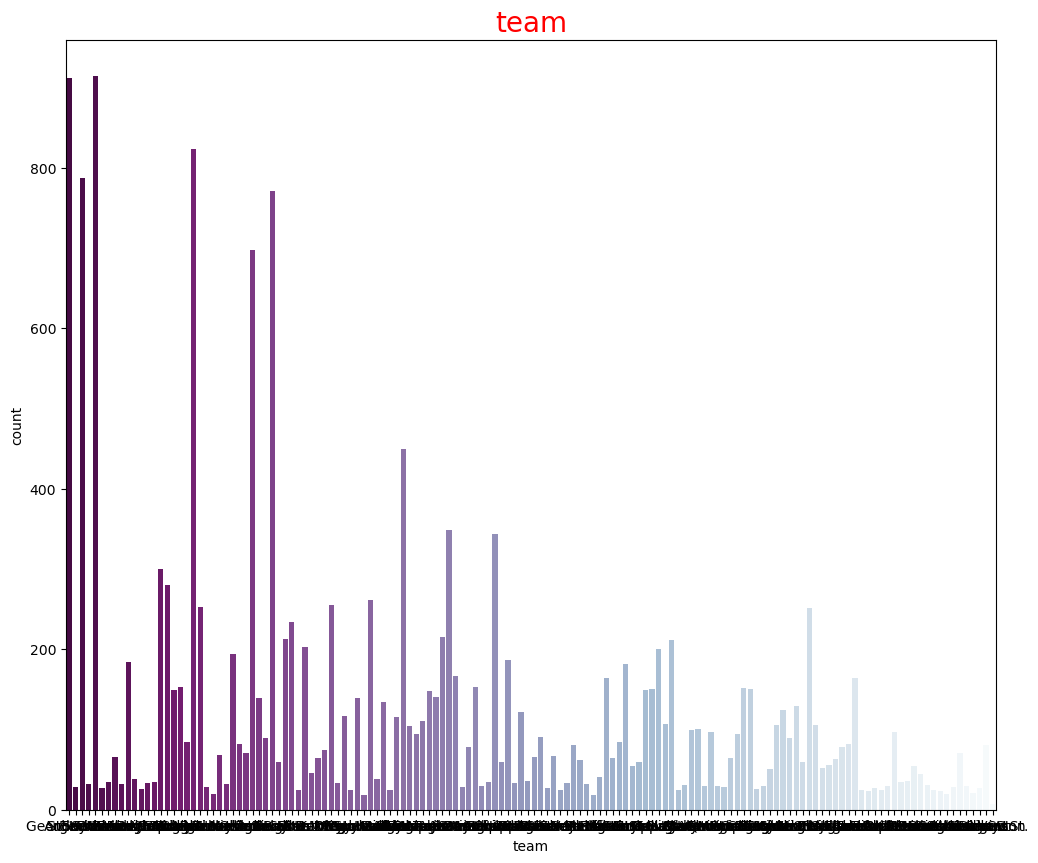

In [40]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,x='team',palette='BuPu_r')
plt.title("team",size=20,color='Red')
plt.show()

In [44]:
combined['id'].value_counts(normalize=True)*100

1-1       0.005733
292-35    0.005733
292-42    0.005733
292-41    0.005733
292-39    0.005733
            ...   
145-27    0.005733
145-28    0.005733
145-29    0.005733
145-32    0.005733
190-31    0.005733
Name: id, Length: 17442, dtype: float64

In [46]:
train.shape[0]

12209

In [47]:
new_train=combined.iloc[0:train.shape[0],:]

In [48]:
new_test=combined.iloc[train.shape[0]:,:]

In [49]:
train.shape,new_train.shape,test.shape,new_test.shape

((12209, 6), (12209, 6), (5233, 5), (5233, 6))

In [50]:
new_test.drop('id',axis=1,inplace=True)

/tmp/ipykernel_32/1138654343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_test.drop('id',axis=1,inplace=True)


In [51]:
import scipy.stats as stats

In [54]:
sig_num=[]
for i in num_cols:
    
    zero=new_train.loc[new_train['id']==0,i]
    one=new_train.loc[new_train['id']==1,i]
    two=new_train.loc[new_train['id']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        
        sig_num.append(i)
        print(i)

In [55]:
sig_cat=[]
for  i in cat_cols:
    a=pd.crosstab(new_train[i],new_train['id'])
    tstat,pval,dof,freq=stats.chi2_contingency(a)
    if pval<0.05:
        sig_cat.append(i)
        print(i)

In [58]:
train_new=new_train.loc[:,sig_cat+sig_num]

In [60]:
test_new=new_test.loc[:,sig_cat+sig_num]

In [ ]:
# Checking for multicollinearity

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [62]:
train_new

""
0
1
2
3
4
...
12204
12205
12206
12207


In [ ]:
# Scaling the cols

In [68]:
scaling=[]

In [69]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [70]:
for i in scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.DataFrame(test_new.loc[:,i]))

In [71]:
train_new

""
0
1
2
3
4
...
12204
12205
12206
12207


In [72]:
test_new

""
0
1
2
3
4
...
5228
5229
5230
5231
